# Linear Regression on the Brainvita Dataset (From Scratch)

This notebook demonstrates your custom `rice_ml` implementation of **Ordinary Least Squares (OLS)** on the Brainvita board-state dataset.

The goal is not only to train a model, but to clearly connect:

1. **Theory** (linear model + least-squares objective)
2. **Implementation** (your `LinearRegression` class)
3. **Interpretation** (metrics, residuals, coefficient meaning)

By the end, this notebook gives a complete baseline regression narrative that we can compare against more expressive models (trees, ensembles, MLP) later.


## 1. Mathematical Intuition

Linear regression assumes a linear relationship between features and target:

$$
\hat{y} = X\beta + \epsilon
$$

- $X$ is the feature matrix
- $\beta$ is the coefficient vector (plus an intercept if enabled)
- $\epsilon$ is residual error

OLS chooses parameters that minimize squared prediction error:

$$
\min_{\beta} \; \|y - X\beta\|_2^2
$$

Setting the gradient to zero yields the normal-equation solution:

$$
\beta^* = (X^T X)^{-1} X^T y
$$

Your implementation uses the **Moore-Penrose pseudo-inverse** (`pinv`) for numerical stability when $X^T X$ is singular or ill-conditioned.


In [1]:
from pathlib import Path
import sys
import csv

import numpy as np
import matplotlib.pyplot as plt


def find_repo_root(start='.'):
    p = Path(start).resolve()
    for q in [p, *p.parents]:
        if (q / 'src' / 'rice_ml').exists() and (q / 'data' / 'brainvita_dataset.csv').exists():
            return q
    raise FileNotFoundError('Could not locate repository root')


ROOT = find_repo_root('.')
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from rice_ml.supervised_learning import LinearRegression

DATA_PATH = ROOT / 'data' / 'brainvita_dataset.csv'
print('Repo root:', ROOT)
print('Dataset path:', DATA_PATH)


Repo root: /Users/LakshSarda/Desktop/CMOR_438_Repository
Dataset path: /Users/LakshSarda/Desktop/CMOR_438_Repository/data/brainvita_dataset.csv


## 2. Load Data and Define Features

We predict:

- **Target:** `num_legal_moves`

Feature selection policy:

- Keep engineered numeric board-state summaries
- Exclude `board_state` (raw serialized board string)
- Exclude explicit move-output columns (`best_move_*`, `worst_move_*`) to avoid leakage from action-specific labels

This keeps the regression task focused on learning from structural board descriptors.


In [2]:
with open(DATA_PATH, 'r', encoding='utf-8') as f:
    header = f.readline().strip().split(',')

print('Total columns:', len(header))
print('Columns:', header)

exclude_cols = {
    'num_legal_moves',
    'board_state',
    'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2',
    'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2',
}

target_col = 'num_legal_moves'
feature_cols = [c for c in header if c not in exclude_cols]
selected_cols = feature_cols + [target_col]
selected_idx = [header.index(c) for c in selected_cols]

arr = np.loadtxt(DATA_PATH, delimiter=',', skiprows=1, usecols=selected_idx, dtype=float)
X = arr[:, :-1]
y = arr[:, -1]

print('Rows:', X.shape[0])
print('Feature count:', X.shape[1])
print('First 10 features:', feature_cols[:10])
print('Target min/mean/max:', float(y.min()), float(y.mean()), float(y.max()))


Total columns: 32
Columns: ['total_pegs', 'total_empty', 'total_holes', 'num_legal_moves', 'peg_ratio', 'mobile_pegs', 'immobile_pegs', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster', 'edge_pegs', 'interior_pegs', 'avg_adjacent_pegs', 'avg_adjacent_empty', 'max_adjacent_empty', 'center_of_mass_r', 'center_of_mass_c', 'spread', 'min_pegs_reachable', 'max_pegs_reachable', 'best_move_r1', 'best_move_c1', 'best_move_r2', 'best_move_c2', 'worst_move_r1', 'worst_move_c1', 'worst_move_r2', 'worst_move_c2', 'board_rows', 'board_cols', 'board_state']


Rows: 238486
Feature count: 22
First 10 features: ['total_pegs', 'total_empty', 'total_holes', 'peg_ratio', 'mobile_pegs', 'immobile_pegs', 'jumpable_pegs', 'mobility_ratio', 'num_clusters', 'largest_cluster']
Target min/mean/max: 1.0 2.0796860193051163 10.0


## 3. Exploratory Data Analysis

Before fitting, we inspect:

- the target distribution
- strongest linear associations with the target

This helps validate whether a linear baseline is sensible and which features are likely to drive predictions.


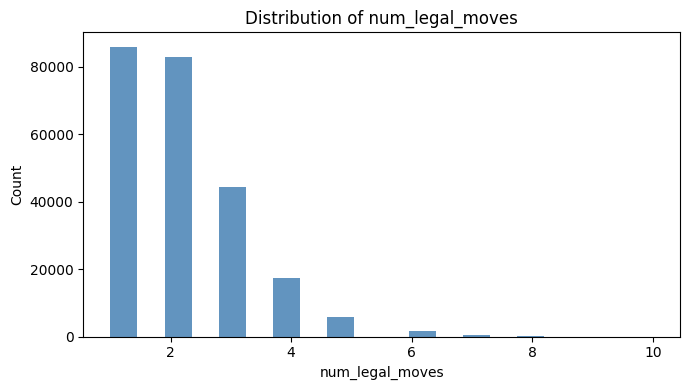

Top feature correlations with num_legal_moves:
           mobile_pegs :  0.9649
         jumpable_pegs :  0.9465
        mobility_ratio :  0.6668
           total_holes :  0.4324
           total_empty :  0.3880
         interior_pegs :  0.3833
    max_pegs_reachable :  0.3478
    min_pegs_reachable : -0.3433
            total_pegs :  0.3263
       largest_cluster :  0.2584
            board_rows :  0.2360
            board_cols :  0.2329


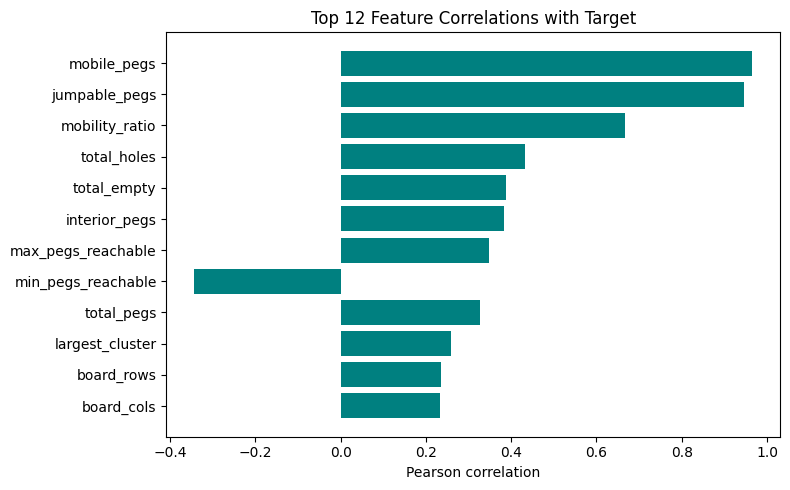

In [3]:
# Target distribution
plt.figure(figsize=(7, 4))
plt.hist(y, bins=20, color='steelblue', alpha=0.85)
plt.title('Distribution of num_legal_moves')
plt.xlabel('num_legal_moves')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Correlation with target
Xy = np.column_stack([X, y])
corr = np.corrcoef(Xy, rowvar=False)
corr_target = corr[:-1, -1]
order = np.argsort(np.abs(corr_target))[::-1]

print('Top feature correlations with num_legal_moves:')
for i in order[:12]:
    print(f'{feature_cols[i]:>22s} : {corr_target[i]: .4f}')

# Horizontal bar chart (top 12)
top_idx = order[:12][::-1]
plt.figure(figsize=(8, 5))
plt.barh([feature_cols[i] for i in top_idx], [corr_target[i] for i in top_idx], color='teal')
plt.title('Top 12 Feature Correlations with Target')
plt.xlabel('Pearson correlation')
plt.tight_layout()
plt.show()


## 4. Preprocessing and Train/Test Split

Pipeline:

1. Random **80/20** split (seeded for reproducibility)
2. Standardize features using **training-set** mean/std only

Why standardize here?

- Coefficients become comparable in magnitude
- Numerical conditioning for linear algebra improves
- Test data remains leakage-safe by using train statistics only


In [4]:
rng = np.random.default_rng(42)
idx = np.arange(X.shape[0])
rng.shuffle(idx)

split = int(0.8 * len(idx))
train_idx, test_idx = idx[:split], idx[split:]

X_train_raw, X_test_raw = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

mu = X_train_raw.mean(axis=0)
sigma = X_train_raw.std(axis=0)
sigma_safe = np.where(sigma < 1e-12, 1.0, sigma)

X_train = (X_train_raw - mu) / sigma_safe
X_test = (X_test_raw - mu) / sigma_safe

print('X_train:', X_train.shape, 'X_test:', X_test.shape)
print('y_train:', y_train.shape, 'y_test:', y_test.shape)


X_train: (190788, 22) X_test: (47698, 22)
y_train: (190788,) y_test: (47698,)


## 5. Fit the Custom Linear Regression Model

We train `LinearRegression(fit_intercept=True)` from your package.

Key learned quantities:

- `intercept_`: global baseline prediction
- `coef_`: per-feature linear effects
- `n_features_in_`: feature-count sanity check stored by the model


In [5]:
model = LinearRegression(fit_intercept=True)
model.fit(X_train, y_train)

print(model)
print('Intercept:', model.intercept_)
print('First 10 coefficients:', model.coef_[:10])
print('n_features_in_:', model.n_features_in_)


LinearRegression(fit_intercept=True)
Intercept: 2.0810933311389435
First 10 coefficients: [-4.20897123e+07 -2.36088322e+08  1.01775819e+09  8.57661734e-02
 -7.85761240e+09 -2.53521957e+10  4.80411814e-01  4.40594903e-02
 -4.38071026e-03 -8.46899887e-02]
n_features_in_: 22


## 6. Evaluate Performance

We report:

- **R²**: proportion of variance explained
- **MSE / RMSE**: squared-error scale
- **MAE**: average absolute prediction error

We also compare against a naive baseline that predicts the training-mean target for every test sample.


In [6]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mse = float(np.mean((y_true - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae = float(np.mean(np.abs(y_true - y_pred)))
    ss_res = float(np.sum((y_true - y_pred) ** 2))
    ss_tot = float(np.sum((y_true - y_true.mean()) ** 2))
    r2 = 1.0 - (ss_res / ss_tot) if ss_tot > 0 else 0.0
    return r2, mse, rmse, mae


y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_r2, train_mse, train_rmse, train_mae = regression_metrics(y_train, y_pred_train)
test_r2, test_mse, test_rmse, test_mae = regression_metrics(y_test, y_pred_test)

baseline_pred = np.full_like(y_test, fill_value=float(y_train.mean()), dtype=float)
base_r2, base_mse, base_rmse, base_mae = regression_metrics(y_test, baseline_pred)

print('Train -> R2: %.4f | MSE: %.4f | RMSE: %.4f | MAE: %.4f' % (train_r2, train_mse, train_rmse, train_mae))
print('Test  -> R2: %.4f | MSE: %.4f | RMSE: %.4f | MAE: %.4f' % (test_r2, test_mse, test_rmse, test_mae))
print('Base  -> R2: %.4f | MSE: %.4f | RMSE: %.4f | MAE: %.4f' % (base_r2, base_mse, base_rmse, base_mae))


Train -> R2: 0.9653 | MSE: 0.0419 | RMSE: 0.2048 | MAE: 0.1379
Test  -> R2: 0.9645 | MSE: 0.0422 | RMSE: 0.2053 | MAE: 0.1385
Base  -> R2: -0.0000 | MSE: 1.1863 | RMSE: 1.0892 | MAE: 0.8302


## 7. Diagnostic Visuals

We use three standard diagnostics:

1. **Predicted vs Actual**: closeness to identity line
2. **Residuals vs Predicted**: structure that may indicate misspecification
3. **Residual histogram**: central tendency and spread of error

Then we inspect top standardized coefficients for interpretability.


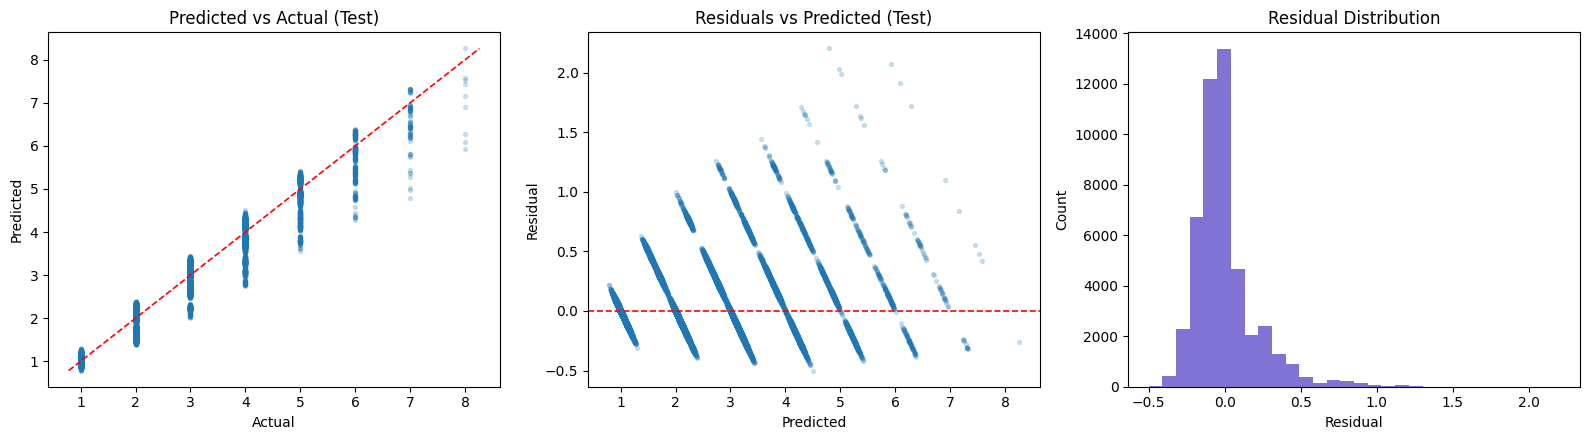

In [7]:
residuals_test = y_test - y_pred_test

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

ax[0].scatter(y_test, y_pred_test, alpha=0.2, s=8)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax[0].plot(lims, lims, 'r--', linewidth=1.2)
ax[0].set_title('Predicted vs Actual (Test)')
ax[0].set_xlabel('Actual')
ax[0].set_ylabel('Predicted')

ax[1].scatter(y_pred_test, residuals_test, alpha=0.2, s=8)
ax[1].axhline(0, color='red', linestyle='--', linewidth=1.2)
ax[1].set_title('Residuals vs Predicted (Test)')
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Residual')

ax[2].hist(residuals_test, bins=30, color='slateblue', alpha=0.85)
ax[2].set_title('Residual Distribution')
ax[2].set_xlabel('Residual')
ax[2].set_ylabel('Count')

plt.tight_layout()
plt.show()


Top 15 coefficients by absolute magnitude:
         immobile_pegs : -25352195679.67432
             edge_pegs :  17183807872.04240
         interior_pegs :  11732127897.66214
           mobile_pegs : -7857612398.06990
           total_holes :  1017758185.22010
           total_empty : -236088321.65142
            total_pegs : -42089712.34851
         jumpable_pegs :  0.48041
             peg_ratio :  0.08577
       largest_cluster : -0.08469
    max_adjacent_empty :  0.05024
     avg_adjacent_pegs :  0.04936
    max_pegs_reachable :  0.04761
        mobility_ratio :  0.04406
    avg_adjacent_empty :  0.01456


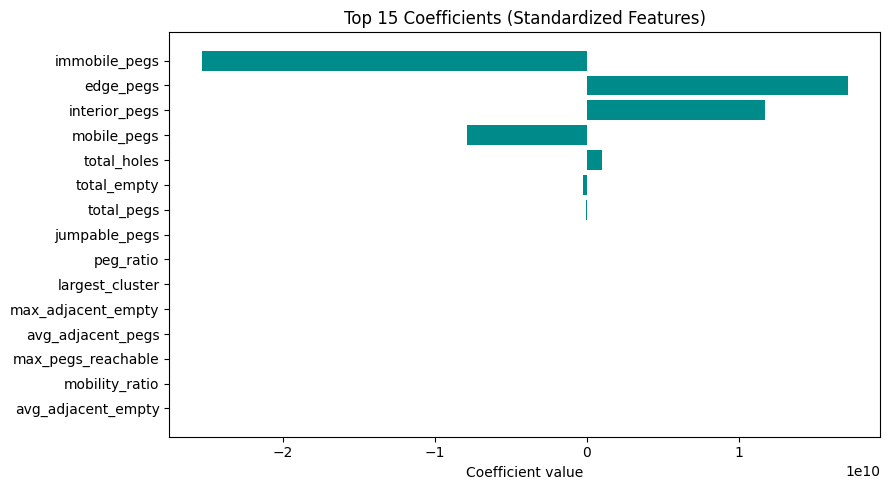

In [8]:
coef = model.coef_
order_coef = np.argsort(np.abs(coef))[::-1]

print('Top 15 coefficients by absolute magnitude:')
for i in order_coef[:15]:
    print(f'{feature_cols[i]:>22s} : {coef[i]: .5f}')

plt.figure(figsize=(9, 5))
show = order_coef[:15][::-1]
plt.barh([feature_cols[i] for i in show], [coef[i] for i in show], color='darkcyan')
plt.title('Top 15 Coefficients (Standardized Features)')
plt.xlabel('Coefficient value')
plt.tight_layout()
plt.show()


## 8. Interpretation and Limitations

Interpretation:

- Positive coefficient: higher feature values tend to increase predicted legal moves
- Negative coefficient: higher feature values tend to decrease predicted legal moves
- Larger absolute coefficient: stronger linear effect (because features were standardized)

Limitations of this baseline:

- Brainvita dynamics can include nonlinear interactions and threshold effects
- OLS cannot natively capture complex feature interactions unless we manually engineer them

Still, this notebook provides a transparent, high-quality baseline that subsequent supervised notebooks should compare against.
